In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv, pinv
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt

In [8]:
class CAMDATS:
    def __init__(self, tau, phi):
        self.tau = tau  # Initial clusters' size
        self.phi = phi  # Clustering factor
        self.clusters = None
        self.centroids = None
        self.cov_matrices = None

    def compute_initial_clusters(self, T):
        clusters = [T[i:i + self.tau] for i in range(0, len(T), self.tau)]
        return clusters

    def compute_centroids(self, clusters):
        centroids = [np.mean(cluster, axis=0) for cluster in clusters]
        return centroids

    def compute_covariance_matrices(self, clusters):
        cov_matrices = [np.cov(cluster, rowvar=False) for cluster in clusters]
        return cov_matrices

    def mahalanobis_distance(self, x, centroids, cov_matrices):
        distances = []
        for centroid, cov_matrix in zip(centroids, cov_matrices):
            # Add a small constant to the diagonal to make the matrix invertible
            reg_cov_matrix = cov_matrix + np.eye(cov_matrix.shape[0]) * 1e-6
            inv_cov_matrix = pinv(reg_cov_matrix)
            distance = mahalanobis(x, centroid, inv_cov_matrix)
            distances.append(distance)
        return distances

    def assign_to_nearest_cluster(self, x, clusters, centroids, cov_matrices):
        distances = self.mahalanobis_distance(x, centroids, cov_matrices)
        nearest_cluster_index = np.argmin(distances)
        clusters[nearest_cluster_index].append(x)
        return clusters

    def rebuild_clusters(self, T, clusters):
        centroids = self.compute_centroids(clusters)
        cov_matrices = self.compute_covariance_matrices(clusters)
        new_clusters = [[] for _ in clusters]
        for i in range(len(T)):
            new_clusters = self.assign_to_nearest_cluster(T[i], new_clusters, centroids, cov_matrices)
        return new_clusters

    def find_anomalous_patterns(self, clusters):
        patterns = []
        while clusters:
            pattern = [clusters.pop(0)]
            for cluster in clusters:
                if self.are_similar(pattern[0], cluster):
                    pattern.append(cluster)
            patterns.append(pattern)
        return patterns

    def are_similar(self, cluster1, cluster2):
        centroid1 = np.mean(cluster1, axis=0)
        centroid2 = np.mean(cluster2, axis=0)
        std_dev = np.std(cluster1 + cluster2, axis=0)
        distance = np.linalg.norm(centroid1 - centroid2)
        return distance <= self.phi * std_dev

    def compute_anomaly_rank(self, pattern):
        total_size = sum(len(cluster) for cluster in pattern)
        return len(pattern) / total_size

    def fit(self, T):
        # Convert pandas DataFrame to numpy array
        T = T.values
        clusters = self.compute_initial_clusters(T)
        while True:
            new_clusters = self.rebuild_clusters(T, clusters)
            if new_clusters == clusters:
                break
            clusters = new_clusters
        self.clusters = clusters
        self.centroids = self.compute_centroids(clusters)
        self.cov_matrices = self.compute_covariance_matrices(clusters)

    def predict(self, T):
        # Convert pandas DataFrame to numpy array
        T = T.values
        distances = [mahalanobis(x, centroid, pinv(cov_matrix + np.eye(cov_matrix.shape[0]) * 1e-6)) for x in T for centroid, cov_matrix in zip(self.centroids, self.cov_matrices)]
        return distances

    def save(self, filepath):
        joblib.dump(self, filepath)

    @staticmethod
    def load(filepath):
        return joblib.load(filepath)


In [27]:
class CAMDATS:
    def __init__(self, tau, phi):
        self.tau = tau  # Initial clusters' size
        self.phi = phi  # Clustering factor
        self.clusters = None
        self.centroids = None
        self.cov_matrices = None

    def compute_initial_clusters(self, T):
        clusters = [T[i:i + self.tau] for i in range(0, len(T), self.tau)]
        return clusters

    def compute_centroids(self, clusters):
        centroids = [np.mean(cluster, axis=0) for cluster in clusters]
        return centroids

    def compute_covariance_matrices(self, clusters):
        cov_matrices = [np.cov(cluster, rowvar=False) for cluster in clusters]
        return cov_matrices

    def mahalanobis_distance(self, x, centroids, cov_matrices):
        distances = []
        for centroid, cov_matrix in zip(centroids, cov_matrices):
            # Add a small constant to the diagonal to make the matrix invertible
            reg_cov_matrix = cov_matrix + np.eye(cov_matrix.shape[0]) * 1e-6
            inv_cov_matrix = pinv(reg_cov_matrix)
            distance = mahalanobis(x, centroid, inv_cov_matrix)
            distances.append(distance)
        return distances

    def assign_to_nearest_cluster(self, x, clusters, centroids, cov_matrices):
        distances = self.mahalanobis_distance(x, centroids, cov_matrices)
        nearest_cluster_index = np.argmin(distances)
        clusters[nearest_cluster_index].append(x)
        return clusters

    def rebuild_clusters(self, T, clusters):
        centroids = self.compute_centroids(clusters)
        cov_matrices = self.compute_covariance_matrices(clusters)
        new_clusters = [[] for _ in clusters]
        for i in range(len(T)):
            new_clusters = self.assign_to_nearest_cluster(T[i], new_clusters, centroids, cov_matrices)
        return new_clusters

    def find_anomalous_patterns(self, clusters):
        patterns = []
        while clusters:
            pattern = [clusters.pop(0)]
            for cluster in clusters:
                if self.are_similar(pattern[0], cluster):
                    pattern.append(cluster)
            patterns.append(pattern)
        return patterns

    def are_similar(self, cluster1, cluster2):
        centroid1 = np.mean(cluster1, axis=0)
        centroid2 = np.mean(cluster2, axis=0)
        std_dev = np.std(cluster1 + cluster2, axis=0)
        distance = np.linalg.norm(centroid1 - centroid2)
        return distance <= self.phi * std_dev

    def compute_anomaly_rank(self, pattern):
        total_size = sum(len(cluster) for cluster in pattern)
        return len(pattern) / total_size

    def fit(self, T):
        # Convert pandas DataFrame to numpy array
        T = T.values
        clusters = self.compute_initial_clusters(T)
        pbar = tqdm(total=len(T), desc="Training")
        step = len(T) // 100  # Update progress bar every 1% of the data
        while True:
            new_clusters = self.rebuild_clusters(T, clusters)
            if all(np.array_equal(a, b) for a, b in zip(clusters, new_clusters)):
                break
            clusters = new_clusters
            pbar.update(step)
        pbar.close()
        self.clusters = clusters
        self.centroids = self.compute_centroids(clusters)
        self.cov_matrices = self.compute_covariance_matrices(clusters)

    def predict(self, T):
        # Convert pandas DataFrame to numpy array
        T = T.values
        distances = []
        pbar = tqdm(total=len(T), desc="Predicting")
        for i in range(len(T)):
            distance = min(mahalanobis(T[i], centroid, pinv(cov_matrix + np.eye(cov_matrix.shape[0]) * 1e-6)) for centroid, cov_matrix in zip(self.centroids, self.cov_matrices))
            distances.append(distance)
            pbar.update(1)
        pbar.close()
        return distances

    def save(self, filepath):
        joblib.dump(self, filepath)

    @staticmethod
    def load(filepath):
        return joblib.load(filepath)

In [28]:
save_directory = './preprocessed_dataset/VG5/op_0'

control_df = pd.read_parquet(path=f'{save_directory}/control.parquet')
sensors_heat_exchanger = pd.read_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')

# Prepare training data - using only heat exchanger sensors
training_df = pd.concat([control_df,sensors_heat_exchanger], axis=1)

print(training_df.shape)

(99218, 16)


In [29]:
training_df_small = training_df[::100]
print(training_df_small.shape)

(993, 16)


In [30]:
# Initialize the C-AMDATS algorithm
tau = 24  # Initial clusters' size
phi = 1.2  # Clustering factor
camdats = CAMDATS(tau, phi)

# Train the model on the training set
camdats.fit(training_df_small)







Training:   2%|▏         | 18/993 [00:38<35:09,  2.16s/it]


In [ ]:
# Save the trained model
camdats.save('camdats_model.pkl')


In [ ]:
# Load the trained model
loaded_camdats = CAMDATS.load('camdats_model.pkl')

In [39]:
### Evaluating on the training set

# Predict anomalies on the training set
anomaly_scores = camdats.predict(training_df_small)

# Print the anomaly scores
for i, score in enumerate(anomaly_scores):
    print(f"Sample {i+1}: Anomaly Score = {score}")

Predicting: 100%|██████████| 993/993 [00:17<00:00, 55.89it/s]

Sample 1: Anomaly Score = 4.420572449004608
Sample 2: Anomaly Score = 3.734783717405809
Sample 3: Anomaly Score = 3.4127992712043875
Sample 4: Anomaly Score = 4.246063785903185
Sample 5: Anomaly Score = 3.1947126893481217
Sample 6: Anomaly Score = 3.4542816898375053
Sample 7: Anomaly Score = 4.407153455626216
Sample 8: Anomaly Score = 3.7603607076149728
Sample 9: Anomaly Score = 3.7903671770157277
Sample 10: Anomaly Score = 4.28282289645105
Sample 11: Anomaly Score = 4.149816344893685
Sample 12: Anomaly Score = 3.0676611974849
Sample 13: Anomaly Score = 3.825899885682541
Sample 14: Anomaly Score = 4.073369375881453
Sample 15: Anomaly Score = 4.462767610004459
Sample 16: Anomaly Score = 4.4398582964049
Sample 17: Anomaly Score = 3.824581765085876
Sample 18: Anomaly Score = 4.168087464260978
Sample 19: Anomaly Score = 3.981845076016515
Sample 20: Anomaly Score = 4.06150690811422
Sample 21: Anomaly Score = 3.7710919706627553
Sample 22: Anomaly Score = 3.9670660873874444
Sample 23: Anomaly

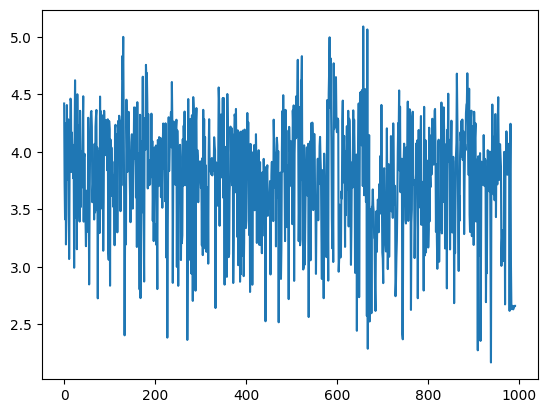

In [40]:
plt.plot(anomaly_scores)

In [31]:
### Evaluating on the second operation period

save_directory = './preprocessed_dataset/VG5/op_1'

valid_control = pd.read_parquet(path=f'{save_directory}/control.parquet')
valid_sensors = pd.read_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')

# Prepare training data - using only heat exchanger sensors
valid_df = pd.concat([valid_control,valid_sensors], axis=1)

print(valid_df.shape)

(57864, 16)


In [34]:
# Predict anomalies on the test set
anomaly_scores = camdats.predict(valid_df[::50])

# Print the anomaly scores
for i, score in enumerate(anomaly_scores):
    print(f"Sample {i+1}: Anomaly Score = {score}")



Predicting: 100%|██████████| 1158/1158 [00:18<00:00, 62.09it/s]

Sample 1: Anomaly Score = 7.74474222524559
Sample 2: Anomaly Score = 7.023136748894369
Sample 3: Anomaly Score = 9.656461747733337
Sample 4: Anomaly Score = 9.069673804343939
Sample 5: Anomaly Score = 8.846531215638258
Sample 6: Anomaly Score = 7.651008106105727
Sample 7: Anomaly Score = 5.42542873527603
Sample 8: Anomaly Score = 5.259274535489902
Sample 9: Anomaly Score = 5.158864084664478
Sample 10: Anomaly Score = 5.318756691618203
Sample 11: Anomaly Score = 10.22997705888114
Sample 12: Anomaly Score = 7.932416203700794
Sample 13: Anomaly Score = 5.214446521548513
Sample 14: Anomaly Score = 8.378503443983094
Sample 15: Anomaly Score = 5.603142328332304
Sample 16: Anomaly Score = 6.358705271232146
Sample 17: Anomaly Score = 4.423974346303222
Sample 18: Anomaly Score = 7.597344657739973
Sample 19: Anomaly Score = 8.395166901045942
Sample 20: Anomaly Score = 7.198522645286082
Sample 21: Anomaly Score = 7.034299304097215
Sample 22: Anomaly Score = 6.736461994269015
Sample 23: Anomaly Sc

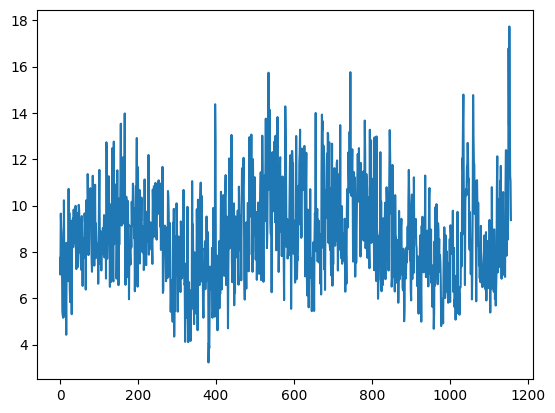

In [ ]:
plt.plot(anomaly_scores)

In [36]:
### Evaluating on the synthetic set

save_directory = './preprocessed_dataset/VG5/s_01'

syn_control = pd.read_parquet(path=f'{save_directory}/control.parquet')
syn_sensors = pd.read_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')

# Prepare training data - using only heat exchanger sensors
syn_df = pd.concat([syn_control,syn_sensors], axis=1)

print(syn_df.shape)

(45229, 16)


In [37]:
# Predict anomalies on the test set
anomaly_scores = camdats.predict(syn_df[::50])

# Print the anomaly scores
for i, score in enumerate(anomaly_scores):
    print(f"Sample {i+1}: Anomaly Score = {score}")

Predicting: 100%|██████████| 905/905 [00:16<00:00, 53.65it/s]

Sample 1: Anomaly Score = 39.81284560804529
Sample 2: Anomaly Score = 83.81249884465174
Sample 3: Anomaly Score = 48.18938452525702
Sample 4: Anomaly Score = 54.30824853922801
Sample 5: Anomaly Score = 41.91619955628099
Sample 6: Anomaly Score = 35.308141124066246
Sample 7: Anomaly Score = 82.44433893059502
Sample 8: Anomaly Score = 81.16424995739916
Sample 9: Anomaly Score = 82.91778137186009
Sample 10: Anomaly Score = 79.31369408713776
Sample 11: Anomaly Score = 101.97593560605236
Sample 12: Anomaly Score = 95.63287771117676
Sample 13: Anomaly Score = 92.79014119237688
Sample 14: Anomaly Score = 31.265266243715885
Sample 15: Anomaly Score = 56.3924833036839
Sample 16: Anomaly Score = 44.52909327200423
Sample 17: Anomaly Score = 39.862739364258516
Sample 18: Anomaly Score = 24.315155281944406
Sample 19: Anomaly Score = 35.483254845326734
Sample 20: Anomaly Score = 51.13588240197778
Sample 21: Anomaly Score = 34.174454492345625
Sample 22: Anomaly Score = 22.550037880379097
Sample 23: A

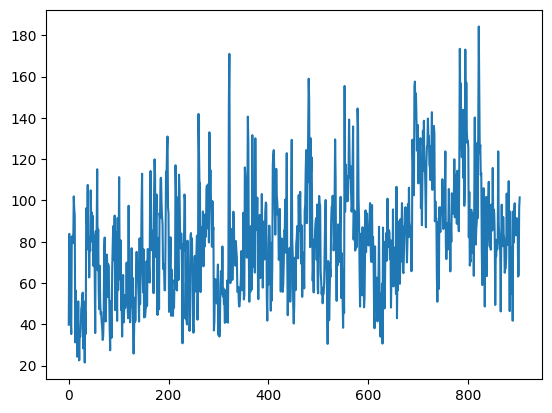

In [38]:
plt.plot(anomaly_scores)